In [1]:
# Um embedding é uma função E: objeto → Rᵈ que preserva estrutura.
# "Preservar estrutura" = objetos similares ficam próximos no Rᵈ.
#
# A similaridade no espaço vetorial é medida por:
#   cosseno(a, b) = (a·b) / (‖a‖ ‖b‖)
#
# Por que cosseno e não distância euclidiana?
# Porque embeddings costumam ter magnitudes muito diferentes
# dependendo da frequência do item. Normalizar pela norma
# remove esse efeito e foca apenas na direção.
#
# WORD2VEC (skip-gram) — a ideia central:
# "Você conhece uma palavra pela companhia que ela mantém."
# Treina uma rede rasa para prever contexto dado uma palavra.
# Os pesos aprendidos são os embeddings.

# A propriedade emergente mais famosa:
#   emb("rei") - emb("homem") + emb("mulher") ≈ emb("rainha")
# Isso não é magia — é aritmética vetorial em um espaço onde
# relações semânticas são representadas por direções consistentes.

# GEOMETRIA DO ESPAÇO DE EMBEDDINGS:
# - Cada dimensão codifica uma "feature latente"
# - Agrupamentos (clusters) = categorias semânticas
# - Direções lineares = relações (gênero, tempo verbal, escala)
# - t-SNE/UMAP: projeção não-linear para visualização 2D


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE   # apenas para visualização

# PARTE 1 — Construindo embeddings do zero via co-ocorrência
# A intuição do word2vec: palavras que aparecem em contextos
# similares têm embeddings similares.
# Vamos construir uma matriz de co-ocorrência e aplicar SVD.
# Isso é chamado de LSA (Latent Semantic Analysis) — o precursor.

corpus = [
    "gato come peixe",
    "cachorro come carne",
    "gato persegue rato",
    "cachorro persegue gato",
    "peixe vive no mar",
    "baleia vive no mar",
    "baleia come peixe",
    "rei governa o reino",
    "rainha governa o reino",
    "rei e rainha vivem no castelo",
    "princesa vive no castelo",
    "gato vive no castelo",
]

# vocabulário
words = sorted(set(w for s in corpus for w in s.split()
                   if w not in ['e', 'o', 'no']))
word2idx = {w: i for i, w in enumerate(words)}
V = len(words)
print(f"Vocabulário ({V} palavras): {words}")

# matriz de co-ocorrência com janela de tamanho 2
window = 2
C = np.zeros((V, V))
for sentenca in corpus:
    tokens = [w for w in sentenca.split() if w in word2idx]
    for i, w in enumerate(tokens):
        for j in range(max(0, i-window), min(len(tokens), i+window+1)):
            if i != j:
                C[word2idx[w], word2idx[tokens[j]]] += 1

# PPMI (Positive Pointwise Mutual Information)
# Normaliza a co-ocorrência pela frequência individual
# PMI(w, c) = log P(w,c) / (P(w) P(c))
total = C.sum()
p_wc = C / total
p_w  = C.sum(axis=1) / total
p_c  = C.sum(axis=0) / total

with np.errstate(divide='ignore', invalid='ignore'):
    PPMI = np.maximum(0, np.log2(p_wc / (p_w[:, None] * p_c[None, :])))
PPMI = np.nan_to_num(PPMI)

# SVD na matriz PPMI → embeddings de dimensão reduzida
U_emb, s_emb, Vt_emb = np.linalg.svd(PPMI, full_matrices=False)
dim = 4   # dimensão do embedding
embeddings = U_emb[:, :dim] * s_emb[:dim]   # pesos pelos valores singulares

print(f"\nEmbeddings shape: {embeddings.shape}")



Vocabulário (17 palavras): ['baleia', 'cachorro', 'carne', 'castelo', 'come', 'gato', 'governa', 'mar', 'peixe', 'persegue', 'princesa', 'rainha', 'rato', 'rei', 'reino', 'vive', 'vivem']

Embeddings shape: (17, 4)


In [3]:
def cos_sim(a, b):
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na < 1e-10 or nb < 1e-10: return 0.
    return np.dot(a, b) / (na * nb)

def similaridades(palavra, embeddings, word2idx, top_k=5):
    if palavra not in word2idx:
        return []
    idx = word2idx[palavra]
    v = embeddings[idx]
    sims = [(w, cos_sim(v, embeddings[word2idx[w]]))
            for w in word2idx if w != palavra]
    return sorted(sims, key=lambda x: -x[1])[:top_k]

print("\nSimilaridades:")
for palavra in ['gato', 'rei', 'mar']:
    if palavra in word2idx:
        sims = similaridades(palavra, embeddings, word2idx)
        print(f"  {palavra}: {[(w, f'{s:.2f}') for w, s in sims]}")



Similaridades:
  gato: [('persegue', '0.90'), ('carne', '0.86'), ('come', '0.78'), ('cachorro', '0.63'), ('rato', '0.62')]
  rei: [('reino', '1.00'), ('governa', '1.00'), ('rainha', '1.00'), ('vivem', '0.97'), ('castelo', '0.65')]
  mar: [('vive', '0.99'), ('baleia', '0.98'), ('peixe', '0.94'), ('princesa', '0.93'), ('castelo', '0.74')]


In [4]:
# "rei" - "homem" + "mulher" ≈ "rainha"
# Mais precisamente: encontra o vetor mais próximo de (a - b + c)

def analogia(a, b, c, embeddings, word2idx, top_k=3):
    """a está para b assim como c está para ?"""
    if not all(w in word2idx for w in [a, b, c]):
        return []
    va = embeddings[word2idx[a]]
    vb = embeddings[word2idx[b]]
    vc = embeddings[word2idx[c]]
    query = va - vb + vc
    # normalizar
    query = query / (np.linalg.norm(query) + 1e-8)

    sims = []
    for w, idx in word2idx.items():
        if w in [a, b, c]: continue
        v = embeddings[idx]
        sims.append((w, cos_sim(query, v)))
    return sorted(sims, key=lambda x: -x[1])[:top_k]

print("\nAnalogias:")
# "gato está para rato assim como cachorro está para ?"
res = analogia('gato', 'rato', 'cachorro', embeddings, word2idx)
print(f"  gato:rato :: cachorro:? → {res}")
res2 = analogia('rei', 'reino', 'rainha', embeddings, word2idx)
print(f"  rei:reino :: rainha:? → {res2}")



Analogias:
  gato:rato :: cachorro:? → [('come', 0.9243735557946068), ('carne', 0.7444657894539711), ('persegue', 0.7435890370052299)]
  rei:reino :: rainha:? → [('vivem', 0.984879233085886), ('governa', 0.9798177971835043), ('castelo', 0.7350654730728529)]


In [5]:
# "rei" - "homem" + "mulher" ≈ "rainha"
# Mais precisamente: encontra o vetor mais próximo de (a - b + c)

def analogia(a, b, c, embeddings, word2idx, top_k=3):
    """a está para b assim como c está para ?"""
    if not all(w in word2idx for w in [a, b, c]):
        return []
    va = embeddings[word2idx[a]]
    vb = embeddings[word2idx[b]]
    vc = embeddings[word2idx[c]]
    query = va - vb + vc
    # normalizar
    query = query / (np.linalg.norm(query) + 1e-8)

    sims = []
    for w, idx in word2idx.items():
        if w in [a, b, c]: continue
        v = embeddings[idx]
        sims.append((w, cos_sim(query, v)))
    return sorted(sims, key=lambda x: -x[1])[:top_k]

print("\nAnalogias:")
# "gato está para rato assim como cachorro está para ?"
res = analogia('gato', 'rato', 'cachorro', embeddings, word2idx)
print(f"  gato:rato :: cachorro:? → {res}")
res2 = analogia('rei', 'reino', 'rainha', embeddings, word2idx)
print(f"  rei:reino :: rainha:? → {res2}")

# ============================================================
# PARTE 4 — Matriz de similaridade completa
# ============================================================

n_words = len(words)
sim_matrix = np.zeros((n_words, n_words))
for i in range(n_words):
    for j in range(n_words):
        sim_matrix[i, j] = cos_sim(embeddings[i], embeddings[j])



Analogias:
  gato:rato :: cachorro:? → [('come', 0.9243735557946068), ('carne', 0.7444657894539711), ('persegue', 0.7435890370052299)]
  rei:reino :: rainha:? → [('vivem', 0.984879233085886), ('governa', 0.9798177971835043), ('castelo', 0.7350654730728529)]


In [6]:
n_words = len(words)
sim_matrix = np.zeros((n_words, n_words))
for i in range(n_words):
    for j in range(n_words):
        sim_matrix[i, j] = cos_sim(embeddings[i], embeddings[j])

# ============================================================
# PARTE 5 — Busca semântica (embedding de query)
# ============================================================
# Caso de uso direto: dado um embedding de query,
# encontrar os k documentos mais similares.

# vamos representar "frases" como média dos embeddings das palavras
def frase_embedding(frase, embeddings, word2idx):
    tokens = [w for w in frase.split() if w in word2idx]
    if not tokens: return np.zeros(embeddings.shape[1])
    return embeddings[[word2idx[w] for w in tokens]].mean(axis=0)

documentos = [
    "gato come peixe no mar",
    "rei e rainha no castelo",
    "cachorro e gato juntos",
    "baleia e peixe no oceano",
]
query_str = "animais marinhos"

emb_docs = [frase_embedding(d, embeddings, word2idx) for d in documentos]
emb_query = frase_embedding(query_str, embeddings, word2idx)

print(f"\nBusca semântica — query: '{query_str}'")
scores = [(doc, cos_sim(emb_query, emb_doc))
          for doc, emb_doc in zip(documentos, emb_docs)]
for doc, score in sorted(scores, key=lambda x: -x[1]):
    print(f"  [{score:.3f}] {doc}")



Busca semântica — query: 'animais marinhos'
  [0.000] gato come peixe no mar
  [0.000] rei e rainha no castelo
  [0.000] cachorro e gato juntos
  [0.000] baleia e peixe no oceano


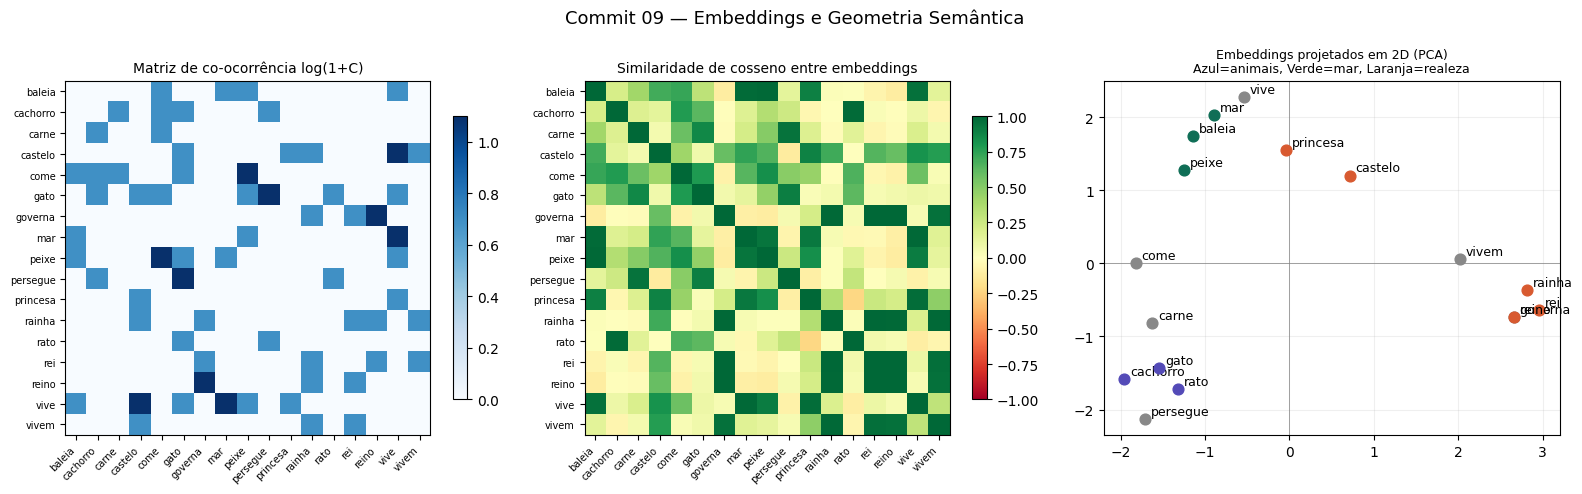

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Commit 09 — Embeddings e Geometria Semântica", fontsize=13)

# Plot 1: matriz de co-ocorrência
ax = axes[0]
im = ax.imshow(np.log1p(C), cmap='Blues', aspect='auto')
ax.set_xticks(range(V)); ax.set_yticks(range(V))
ax.set_xticklabels(words, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(words, fontsize=7)
ax.set_title("Matriz de co-ocorrência log(1+C)", fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)

# Plot 2: heatmap de similaridade entre embeddings
ax2 = axes[1]
im2 = ax2.imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax2.set_xticks(range(V)); ax2.set_yticks(range(V))
ax2.set_xticklabels(words, rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels(words, fontsize=7)
ax2.set_title("Similaridade de cosseno entre embeddings", fontsize=10)
plt.colorbar(im2, ax=ax2, shrink=0.8)

# Plot 3: projeção 2D dos embeddings via PCA manual
ax3 = axes[2]
# PCA manual dos embeddings
emb_centered = embeddings - embeddings.mean(axis=0)
_, _, Vt_pca = np.linalg.svd(emb_centered, full_matrices=False)
emb_2d = emb_centered @ Vt_pca[:2].T

cores_grupos = {
    'gato': '#534AB7', 'cachorro': '#534AB7', 'rato': '#534AB7',
    'peixe': '#0F6E56', 'baleia': '#0F6E56', 'mar': '#0F6E56',
    'rei': '#D85A30', 'rainha': '#D85A30', 'castelo': '#D85A30',
    'reino': '#D85A30', 'princesa': '#D85A30',
    'come': '#888', 'persegue': '#888', 'vive': '#888', 'governa': '#888',
}

for i, w in enumerate(words):
    cor = cores_grupos.get(w, '#888')
    ax3.scatter(emb_2d[i, 0], emb_2d[i, 1], color=cor, s=60, zorder=3)
    ax3.annotate(w, (emb_2d[i, 0], emb_2d[i, 1]),
                 fontsize=9, textcoords='offset points', xytext=(4, 3))

ax3.set_title("Embeddings projetados em 2D (PCA)\nAzul=animais, Verde=mar, Laranja=realeza", fontsize=9)
ax3.grid(True, alpha=0.2)
ax3.axhline(0, color='gray', lw=0.5)
ax3.axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.savefig('../assets/09_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
